## 04 Demand Forecasting: Prophet vs SARIMA

**Input:** 
- data/ventas_clean.csv

**Business problem:** The seller needs to plan inventory and cash flow 3-4 months ahead.  
In Argentina inflation distorts nominal revenue, seasonality is strong.



## Setup

In [1]:
import os
import pathlib
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tsa.statespace.sarimax import SARIMAX

ROOT = pathlib.Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

C = dict(
    bg='#0A0E17', surface='#111827', surf2='#1A2235',
    border='#1E2D45', accent='#00E5A0', gold='#F5C842',
    red='#FF4D6A', blue='#4D9FFF', orange='#E8883A',
    text='#E8EDF5', muted='#6B7A99',
)

mpl.rcParams.update({
    'figure.facecolor': C['bg'], 'axes.facecolor': C['surface'],
    'axes.edgecolor': C['border'], 'axes.labelcolor': C['muted'],
    'axes.titlecolor': C['text'], 'text.color': C['text'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': C['border'], 'grid.linewidth': 0.6,
    'xtick.color': C['muted'], 'ytick.color': C['muted'],
    'font.family': 'DejaVu Sans',
})

os.makedirs(ROOT / 'plots', exist_ok=True)

df = pd.read_csv(ROOT / 'data' / 'ventas_clean.csv', parse_dates=['date'])
print(f'Dataset loaded: {len(df):,} orders')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Real revenue available: {df["gross_revenue_real"].notna().sum():,} rows ({df["gross_revenue_real"].notna().mean()*100:.1f}%)')

Dataset loaded: 353 orders
Date range: 2023-01-06 -> 2026-04-01
Real revenue available: 352 rows (99.7%)


## Monthly Series

In [2]:
monthly = (
    df.groupby(df['date'].dt.to_period('M'))
    .agg(
        y_nominal = ('gross_revenue', 'sum'),
        y_real = ('gross_revenue_real', 'sum'),
        orders = ('order_id', 'count'),
        cpi_mean  = ('cpi_index', 'mean'),
    )
    .reset_index()
)
monthly.columns = ['period', 'y_nominal', 'y_real', 'orders', 'cpi_mean']
monthly['ds'] = monthly['period'].dt.to_timestamp()

monthly_real = monthly.dropna(subset=['y_real']).copy().reset_index(drop=True)

print(f'Monthly series: {len(monthly)} months total')
print(f'With real rev: {len(monthly_real)} months (used for forecasting)')
print(f'Date range: {monthly_real["ds"].min().date()} -> {monthly_real["ds"].max().date()}')
print()
print('Revenue stats (real, Jan 2023 ARS):')
print(monthly_real['y_real'].describe().round(0).to_string())

Monthly series: 40 months total
With real rev: 40 months (used for forecasting)
Date range: 2023-01-01 -> 2026-04-01

Revenue stats (real, Jan 2023 ARS):
count       40.0
mean      9717.0
std       6683.0
min          0.0
25%       4775.0
50%       7594.0
75%      11873.0
max      30579.0


## Outlier Detection and Handling

In [3]:
monthly_real['z'] = (
    (monthly_real['y_real'] - monthly_real['y_real'].mean())
    / monthly_real['y_real'].std()
)

outliers = monthly_real[monthly_real['z'].abs() > 2]
print(f'Outlier months detected (|z| > 2): {len(outliers)}')
if len(outliers) > 0:
    print(outliers[['ds', 'y_real', 'z']].to_string(index=False))

median_clean = monthly_real[monthly_real['z'].abs() <= 2]['y_real'].median()
monthly_real['y_model'] = monthly_real['y_real'].copy()
monthly_real.loc[monthly_real['z'].abs() > 2, 'y_model'] = median_clean

print(f'\nMedian of clean months: ${median_clean:,.0f} ARS real')
print('Outlier months capped at median for training; original values kept in y_real.')
print('Note: outliers can be either high or low - both distort trend estimation.')


Outlier months detected (|z| > 2): 2
        ds       y_real        z
2023-08-01 28195.523914 2.765252
2023-09-01 30578.925832 3.121913

Median of clean months: $7,382 ARS real
Outlier months capped at median for training; original values kept in y_real.
Note: outliers can be either high or low - both distort trend estimation.


## Multiplicative Seasonality

In [4]:
# Demonstrate: compute monthly deviation from annual average per year
monthly_real['year']  = monthly_real['ds'].dt.year
monthly_real['month'] = monthly_real['ds'].dt.month

annual_avg = monthly_real.groupby('year')['y_model'].mean()
monthly_real['vs_avg_pct'] = (
    monthly_real['y_model']
    / monthly_real['year'].map(annual_avg)
    - 1
) * 100

print('Monthly deviation from that year\'s average (%)')
print('Consistent % pattern across years -> multiplicative is correct')
print()
pivot = monthly_real.pivot_table(
    index='month', columns='year', values='vs_avg_pct', aggfunc='mean'
).round(1)
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot)]
print(pivot.to_string())

Monthly deviation from that year's average (%)
Consistent % pattern across years -> multiplicative is correct

year  2023  2024  2025   2026
Jan   65.8  99.9  73.0   23.8
Feb  -12.7  12.3  38.8  109.6
Mar    4.2   9.5  36.7  -33.4
Apr   47.3  55.6   5.9 -100.0
May  -13.5  -2.5 -22.7    NaN
Jun   42.6 -77.5 -31.1    NaN
Jul    7.4 -30.2   6.2    NaN
Aug  -45.3 -34.4  16.2    NaN
Sep  -45.3  18.9 -29.1    NaN
Oct  -22.4 -27.9 -36.2    NaN
Nov    8.6 -29.9 -45.8    NaN
Dec  -36.7   6.2 -11.9    NaN


## Train Prophet

In [5]:
prophet_df = monthly_real[['ds','y_model']].rename(columns={'y_model': 'y'})

model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,   
    daily_seasonality = False,
    seasonality_mode = 'multiplicative', 
    changepoint_prior_scale = 0.05,   
    interval_width = 0.80,   
)

model.fit(prophet_df)
print(f'Prophet trained on {len(prophet_df)} monthly observations')
print(f'Changepoints detected: {len(model.changepoints)}')
print(f'Seasonality mode: {model.seasonality_mode}')

20:02:19 - cmdstanpy - INFO - Chain [1] start processing
20:02:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained on 40 monthly observations
Changepoints detected: 25
Seasonality mode: multiplicative


## Temporal Cross-Validation

In [6]:
print('Running temporal cross-validation...')

cv_results = cross_validation(
    model,
    initial = '548 days',
    period  = '90 days',
    horizon = '90 days',
)

pm = performance_metrics(cv_results)
print('Available metrics:', list(pm.columns))

# Use whichever MAPE column Prophet exposes.
mape_col = 'mape' if 'mape' in pm.columns else 'mdape' if 'mdape' in pm.columns else None
mae_col = 'mae' if 'mae' in pm.columns else None

prophet_mape = pm[mape_col].mean() * 100 if mape_col else None
prophet_mae = pm[mae_col].mean() if mae_col  else None

print('Prophet CV results:')
if prophet_mape is not None:
    print(f'MAPE: {prophet_mape:.1f}%')
if prophet_mae is not None:
    print(f'MAE: ${prophet_mae:,.0f} ARS real')
print(f'Folds: {cv_results["cutoff"].nunique()}')


Running temporal cross-validation...


  0%|          | 0/7 [00:00<?, ?it/s]20:02:20 - cmdstanpy - INFO - Chain [1] start processing
20:02:31 - cmdstanpy - INFO - Chain [1] done processing
 14%|█▍        | 1/7 [00:10<01:05, 10.92s/it]20:02:31 - cmdstanpy - INFO - Chain [1] start processing
20:02:42 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 2/7 [00:22<00:55, 11.10s/it]20:02:42 - cmdstanpy - INFO - Chain [1] start processing
20:02:42 - cmdstanpy - INFO - Chain [1] done processing
 43%|████▎     | 3/7 [00:22<00:24,  6.16s/it]20:02:42 - cmdstanpy - INFO - Chain [1] start processing
20:02:43 - cmdstanpy - INFO - Chain [1] done processing
 57%|█████▋    | 4/7 [00:22<00:11,  3.82s/it]20:02:43 - cmdstanpy - INFO - Chain [1] start processing
20:02:43 - cmdstanpy - INFO - Chain [1] done processing
 71%|███████▏  | 5/7 [00:22<00:05,  2.54s/it]20:02:43 - cmdstanpy - INFO - Chain [1] start processing
20:02:43 - cmdstanpy - INFO - Chain [1] done processing
 86%|████████▌ | 6/7 [00:23<00:01,  1.80s/it]20:02:43 - cmds

Available metrics: ['horizon', 'mse', 'rmse', 'mae', 'mdape', 'smape', 'coverage']
Prophet CV results:
MAPE: inf%
MAE: $7,826 ARS real
Folds: 7


## SARIMA Baseline

In [7]:
y = monthly_real['y_model'].values
actuals, preds = [], []

# Guard: need at least 3 months after cutoff=20 to run any fold.
if len(y) < 23:
    print(f'WARNING: only {len(y)} months — too short for SARIMA CV. Skipping.')
    sarima_mae  = float('nan')
    sarima_mape = float('nan')
else:
    for cutoff in range(20, len(y) - 2, 3):
        try:
            sarima_fit = SARIMAX(
                y[:cutoff],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 0, 12),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            horizon = min(3, len(y) - cutoff)
            sarima_fc = sarima_fit.forecast(horizon)   # named sarima_fc, not fc
            actuals.extend(y[cutoff:cutoff + horizon])
            preds.extend(sarima_fc)
        except Exception:
            pass

    actuals = np.array(actuals)
    preds   = np.array(preds).clip(min=0)

    sarima_mae  = np.mean(np.abs(actuals - preds))
    sarima_mape = np.mean(np.abs((actuals - preds) / actuals.clip(min=1))) * 100

    print(f'SARIMA CV results (expanding window, {len(actuals)} data points):')
    print(f'  MAPE : {sarima_mape:.1f}%')
    print(f'  MAE  : ${sarima_mae:,.0f} ARS real')


c:\Users\danie\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA CV results (expanding window, 18 data points):
  MAPE : 73.4%
  MAE  : $4,740 ARS real


## Model Comparison

In [8]:
def _fmt_mape(v):
    return f'{v:>7.1f}%' if v is not None and not (isinstance(v, float) and v != v) else 'n/a'

def _fmt_mae(v):
    return f'${v:>12,.0f}' if v is not None and not (isinstance(v, float) and v != v) else 'n/a'

print(f'{"Model":<30} {"MAPE":>8} {"MAE":>14}')
print(f'{"SARIMA(1,1,1)(1,1,0,12)":<30} {_fmt_mape(sarima_mape)} {_fmt_mae(sarima_mae)}')
print(f'{"Prophet (multiplicative)":<30} {_fmt_mape(prophet_mape)} {_fmt_mae(prophet_mae)}')
print()

if prophet_mape is not None and sarima_mape == sarima_mape:
    
    winner = 'SARIMA' if sarima_mape < prophet_mape else 'Prophet'
    print(f'Lower MAPE: {winner}')
    print()

print('Model choice: Prophet')
print('Reason 1: trend + seasonality components are directly interpretable')
print('-> August is ~30% above average')
print('Reason 2: with only ~40 months of data, interpretability outweighs')
print('marginal accuracy gains from SARIMA')
print('Reason 3: Prophet handles irregular gaps and outliers more gracefully')
print()
print('Note: Prophet CV and SARIMA CV use the same horizon (90 days) but differ')
print('in number of folds - directionally comparable, not perfectly apples-to-apples.')


Model                              MAPE            MAE
SARIMA(1,1,1)(1,1,0,12)           73.4% $       4,740
Prophet (multiplicative)           inf% $       7,826

Lower MAPE: SARIMA

Model choice: Prophet
Reason 1: trend + seasonality components are directly interpretable
-> August is ~30% above average
Reason 2: with only ~40 months of data, interpretability outweighs
marginal accuracy gains from SARIMA
Reason 3: Prophet handles irregular gaps and outliers more gracefully

Note: Prophet CV and SARIMA CV use the same horizon (90 days) but differ
in number of folds - directionally comparable, not perfectly apples-to-apples.


## Month Forecast

In [9]:
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

last = monthly_real['ds'].max()
fc = forecast[forecast['ds'] > last].copy()

# Convert real forecast back to nominal ARS using projected CPI.
# Assumes inflation continues at the average monthly rate of the last 2 months.
cpi_clean = monthly_real['cpi_mean'].dropna()   
last_cpi  = cpi_clean.iloc[-1]

if len(cpi_clean) >= 3:
    recent_monthly = (cpi_clean.iloc[-1] / cpi_clean.iloc[-3]) ** (1 / 2) - 1
else:
    recent_monthly = 0.0
    print('WARNING: fewer than 3 CPI observations - nominal forecast assumes 0% monthly inflation.')

fc['months_ahead'] = range(1, len(fc) + 1)
fc['cpi_projected'] = last_cpi * (1 + recent_monthly) ** fc['months_ahead']
fc['yhat_nominal'] = fc['yhat'].clip(lower=0) / last_cpi * fc['cpi_projected']

print('6-Month Forecast (real = IPC-deflated ARS, nominal = projected current ARS)')
print(f'Assumed monthly IPC rate: {recent_monthly * 100:.1f}% (geometric avg of last 2 months)')
print()
print(f'{"Month":<12} {"Real (central)":>16} {"Real (80% CI)":>26} {"Nominal (est.)":>16}')
for _, row in fc.iterrows():
    lo = max(row['yhat_lower'], 0)
    hi = row['yhat_upper']
    print(f"{row['ds'].strftime('%b %Y'):<12}"
          f" ${max(row['yhat'], 0):>14,.0f}"
          f"   [${lo:>10,.0f} – ${hi:>10,.0f}]"
          f" ${row['yhat_nominal']:>14,.0f}")
print()
print(f'Total 6-month central (real): ${fc["yhat"].clip(lower=0).sum():,.0f} ARS')
print(f'Total 6-month central (nom.): ${fc["yhat_nominal"].sum():,.0f} ARS')


6-Month Forecast (real = IPC-deflated ARS, nominal = projected current ARS)
Assumed monthly IPC rate: 2.8% (geometric avg of last 2 months)

Month          Real (central)              Real (80% CI)   Nominal (est.)
May 2026     $         2,575   [$         0 – $     5,419] $         2,647
Jun 2026     $         3,085   [$       371 – $     5,981] $         3,261
Jul 2026     $         2,618   [$         0 – $     5,558] $         2,844
Aug 2026     $         1,550   [$         0 – $     4,465] $         1,731
Sep 2026     $         1,514   [$         0 – $     4,449] $         1,738
Oct 2026     $         1,492   [$         0 – $     4,357] $         1,761

Total 6-month central (real): $12,834 ARS
Total 6-month central (nom.): $13,981 ARS


## Visualization


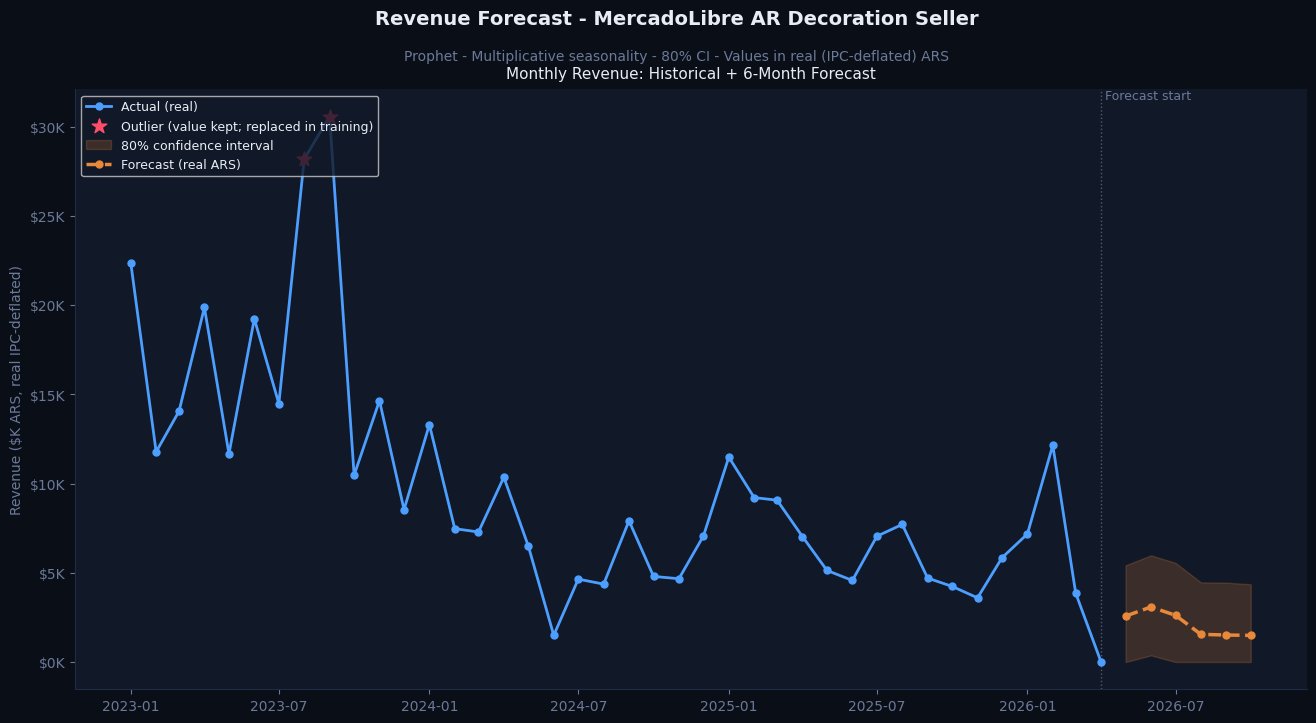

In [10]:
fig = plt.figure(figsize=(14, 8), facecolor=C['bg'])
fig.text(0.5, 0.97, 'Revenue Forecast - MercadoLibre AR Decoration Seller',
         ha='center', va='top', fontsize=14, fontweight='bold', color=C['text'])
fig.text(0.5, 0.92,
         'Prophet - Multiplicative seasonality - 80% CI - Values in real (IPC-deflated) ARS',
         ha='center', va='top', fontsize=10, color=C['muted'])

ax = fig.add_axes([0.07, 0.12, 0.88, 0.75])

# Historical real revenue
ax.plot(monthly_real['ds'], monthly_real['y_real'] / 1e3,
        color=C['blue'], linewidth=2, marker='o', markersize=5,
        label='Actual (real)', zorder=3)

# Outliers marked on the actual (not adjusted) value
if len(outliers) > 0:
    ax.scatter(outliers['ds'], outliers['y_real'] / 1e3,
               color=C['red'], s=120, zorder=5, marker='*',
               label='Outlier (value kept; replaced in training)')

# Forecast CI band
ax.fill_between(fc['ds'],
                fc['yhat_lower'].clip(lower=0) / 1e3,
                fc['yhat_upper'] / 1e3,
                alpha=0.2, color=C['orange'], label='80% confidence interval')

# Forecast central line
ax.plot(fc['ds'], fc['yhat'].clip(lower=0) / 1e3,
        color=C['orange'], linewidth=2.5, linestyle='--',
        marker='o', markersize=5, label='Forecast (real ARS)', zorder=4)

ax.axvline(last, color=C['muted'], linewidth=1, linestyle=':', alpha=0.7)
ax.text(last, 1.0, ' Forecast start',
        color=C['muted'], fontsize=9, va='top',
        transform=ax.get_xaxis_transform())   # x in data coords, y in axes fraction

ax.set_title('Monthly Revenue: Historical + 6-Month Forecast', fontsize=11, pad=8)
ax.set_ylabel('Revenue ($K ARS, real IPC-deflated)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(loc='upper left', fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']:
    ax.spines[sp].set_color(C['border'])

plt.savefig(ROOT / 'plots' / '18_forecast.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()


## Model Components - Actionable Seasonality

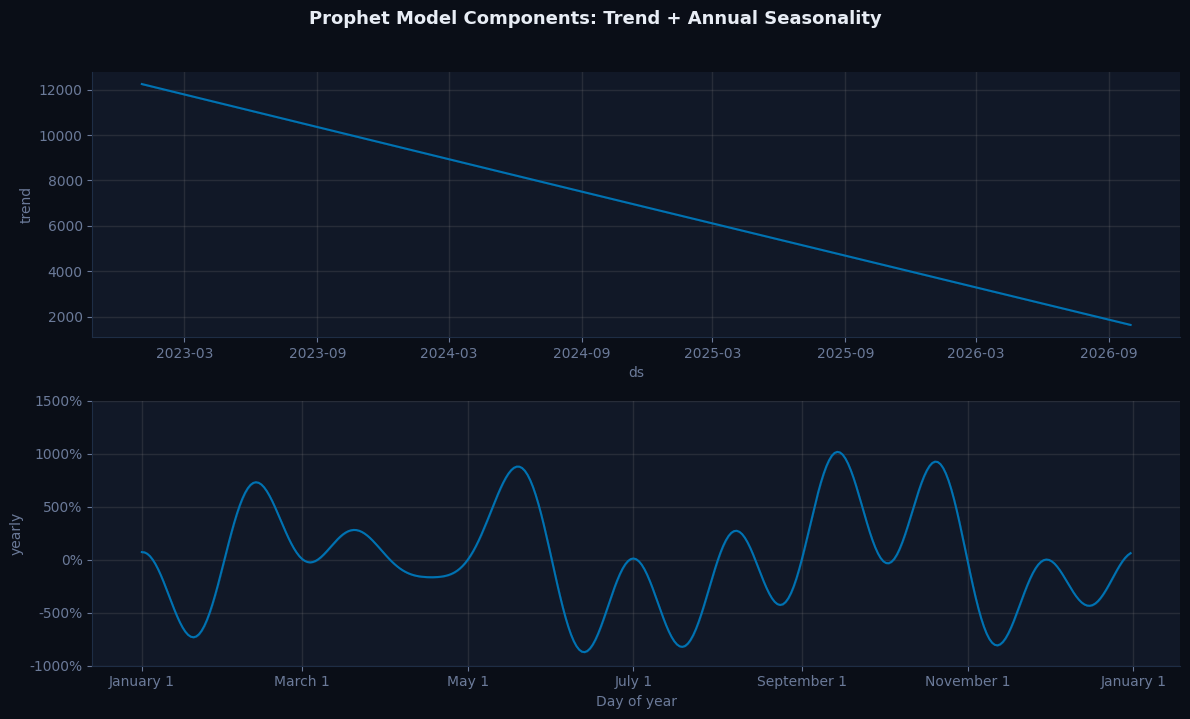

Seasonal factors by month (multiplicative):
Positive = above annual average, negative = below

Jan  + 70.3%  ++++++++++++++
Feb  + 22.8%  ++++
Mar  + 10.4%  ++
Apr  + 40.8%  ++++++++
May   -4.1%  
Jun  +  5.1%  +
Jul  + 11.2%  ++
Aug  -17.0%  ---
Sep   -6.5%  -
Oct  -11.6%  --
Nov   -0.0%  
Dec   -1.8%  


In [11]:
fig_comp = model.plot_components(forecast)
fig_comp.set_size_inches(12, 7)
fig_comp.set_facecolor(C['bg'])
for ax in fig_comp.axes:
    ax.set_facecolor(C['surface'])
    ax.tick_params(colors=C['muted'])
    ax.title.set_color(C['text'])
    for spine in ax.spines.values():
        spine.set_edgecolor(C['border'])
fig_comp.suptitle('Prophet Model Components: Trend + Annual Seasonality',
                   fontsize=13, fontweight='bold', color=C['text'], y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots' / '19_components.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

if 'yearly' not in forecast.columns:
    print('No yearly seasonality component in forecast - skipping seasonal factor table.')
else:
    season = forecast[['ds', 'yearly']].copy()
    season['month'] = season['ds'].dt.month
    season['month_name'] = season['ds'].dt.strftime('%b')
    by_month = (
        season.groupby(['month', 'month_name'])['yearly']
        .mean()
        .reset_index()
        .sort_values('month')
    )

    print('Seasonal factors by month (multiplicative):')
    print('Positive = above annual average, negative = below')
    print()
    for _, row in by_month.iterrows():
        bar = '+' * int(abs(row['yearly']) * 20) if row['yearly'] >= 0 else '-' * int(abs(row['yearly']) * 20)
        sign = '+' if row['yearly'] >= 0 else ''
        print(f"{row['month_name']:<4} {sign}{row['yearly'] * 100:>5.1f}%  {bar}")


In [12]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(ROOT / "data" / "forecast_6meses.csv", index=False)
print("Saved: data/forecast_6meses.csv")

Saved: data/forecast_6meses.csv


## 12. Limitations & Caveats

**Data constraints:**
- ~40 months of history, limited for capturing multi-year cycles
- IPC deflation uses official INDEC rates, which may lag actual market prices
- The April 2026 data point has no IPC yet, so it was excluded from training

**Model constraints:**
- Prophet assumes the seasonal pattern is stable, may not hold if the business shifts catalog
- SARIMA baseline uses only 12-month seasonality, a decoration business may have sub-annual cycles
- The nominal conversion assumes a fixed recent monthly IPC rate, actual future inflation may differ

**What this forecast is good for:**
- Inventory planning (which months to stock more)
- Cash flow estimation (order of magnitude, not exact)
- Identifying anomalies (months that deviate significantly from forecast)

**What it should not be used for:**
- Precise revenue targets
- Decisions that require daily/weekly granularity